PROBLEM STATEMENT:
Analyze caffeine consumption patterns among university students to:
1. Predict exam caffeine consumption from regular consumption (Regression)
2. Classify caffeine consumers into categories (Classification)
3. Identify student clusters based on consumption habits (Clustering)
4. Detect outliers in caffeine consumption behavior (Outlier Analysis)
5. Reduce dimensionality for visualization (PCA)

Dataset: Student caffeine consumption survey with 300+ responses from students of faculty of science MSU Baroda

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, accuracy_score, silhouette_score, r2_score
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("CAFFEINE CONSUMPTION ANALYSIS")
df = pd.read_csv("C:\\Users\\sniks\\caffeine-consumption-ml-app - Copy\\data\\analysiss.csv")

def clean_name(name):
    name = name.strip()
    name = name.replace('[', '').replace(']', '')
    name = name.replace(',', '')
    name = name.replace(' ', '_')
    return name.lower()

df.columns = [clean_name(col) for col in df.columns]

# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)
df.columns = df.columns.str.replace('Spednding', 'Spending')

#consumption columns to numeric
caffeine_cols = ['black_coffee_regular', 'cold_coffee_regular', 'regular_coffee_regular', 'black_coffee_during_exam', 'cold_coffee_during_exam', 'regular_coffee_during_exam', 'green_tea_regular', 'black_tea_regular', 'regular_tea_regular', 'green_tea_during_exam', 'black_tea_during_exam', 'regular_tea_during_exam', 'milky_bar_munch_kit-kat_etc._regular', 'milky_bar_munch_kit-kat_etc._during_exam']
for col in caffeine_cols:
    if col in df.columns:
        df[col] = df[col].replace('More than 4', 5)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

#spending columns to numeric
spending_cols = ['spending_regular_coffee', 'spending_regular_tea', 'spending_exam_coffee', 'spending_exam_tea']
for col in spending_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

#Feature engineering
df['total_coffee_regular'] = df.get('black_coffee_regular', 0) + df.get('cold_coffee_regular', 0) + df.get('regular_coffee_regular', 0)
df['total_coffee_exam'] = df.get('black_coffee_during_exam', 0) + df.get('cold_coffee_during_exam', 0) + df.get('regular_coffee_during_exam', 0)
df['total_tea_regular'] = df.get('green_tea_regular', 0) + df.get('black_tea_regular', 0) + df.get('regular_tea_regular', 0)
df['total_tea_exam'] = df.get('green_tea_during_exam', 0) + df.get('black_tea_during_exam', 0) + df.get('regular_tea_during_exam', 0)

df['total_caffeine_regular'] = df['total_coffee_regular'] + df['total_tea_regular']
df['total_caffeine_exam'] = df['total_coffee_exam'] + df['total_tea_exam']
df['caffeine_increase'] = df['total_caffeine_exam'] - df['total_caffeine_regular']

df['total_spending_regular'] = df.get('spending_regular_coffee', 0) + df.get('spending_regular_tea', 0)
df['total_spending_exam'] = df.get('spending_exam_coffee', 0) + df.get('spending_exam_tea', 0)
df['spending_increase'] = df['total_spending_exam'] - df['total_spending_regular']

#Derived features
df['coffee_tea_ratio'] = df['total_coffee_regular'] / df['total_tea_regular'].replace(0, np.nan)
df['spending_per_cup'] = df['total_spending_regular'] / df['total_caffeine_regular'].replace(0, np.nan)

#Encoding
if 'do_you_consume_caffeine?' in df.columns:
    df['consumes_caffeine'] = df['do_you_consume_caffeine?'].str.strip().str.lower().map({'yes': 1, 'no': 0})
else:
    df['consumes_caffeine'] = 0

print(f"Total records: {len(df)}")
print(f"Caffeine consumers: {df['consumes_caffeine'].sum():.0f} ({df['consumes_caffeine'].mean()*100:.1f}%)")
print(f"Avg regular caffeine: {df['total_caffeine_regular'].mean():.2f} cups/day")
print(f"Avg exam caffeine: {df['total_caffeine_exam'].mean():.2f} cups/day")
print(f"Caffeine increase during exams: {df['caffeine_increase'].mean():.2f} cups/day")


CAFFEINE CONSUMPTION ANALYSIS
Total records: 320
Caffeine consumers: 207 (69.5%)
Avg regular caffeine: 1.05 cups/day
Avg exam caffeine: 1.63 cups/day
Caffeine increase during exams: 0.58 cups/day


### **Dataset Overview**

A survey of **320 students** was analyzed to study caffeine consumption behavior:

* **Caffeine consumers:** 207 students (**69.5%**)
* **Average regular intake:** **1.05 cups/day**
* **Average exam intake:** **1.63 cups/day**
* **Students significantly **increase caffeine intake during exams**
  (**+0.58 cups/day**, much higher than regular days)

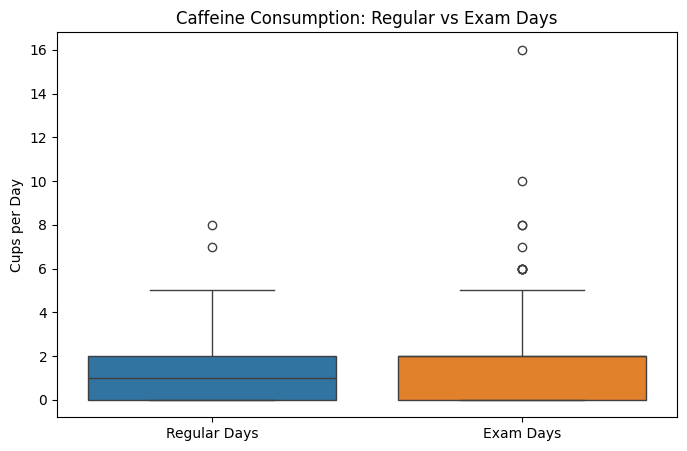

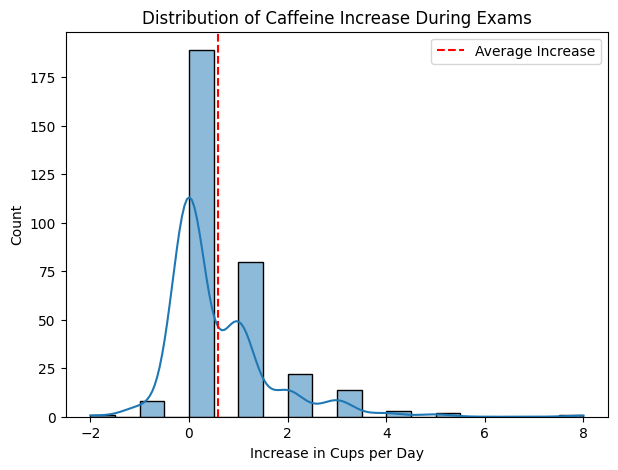

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df[['total_caffeine_regular','total_caffeine_exam']])
plt.xticks([0,1], ['Regular Days', 'Exam Days'])
plt.ylabel("Cups per Day")
plt.title("Caffeine Consumption: Regular vs Exam Days")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df['caffeine_increase'], bins=20, kde=True)
plt.axvline(df['caffeine_increase'].mean(), color='red', linestyle='--', label='Average Increase')
plt.title("Distribution of Caffeine Increase During Exams")
plt.xlabel("Increase in Cups per Day")
plt.legend()
plt.show()


In [5]:
print("1. LINEAR REGRESSION - Predict Exam Consumption")
X_reg = df[['total_coffee_regular', 'total_tea_regular', 'total_spending_regular', 'milky_bar_munch_kit-kat_etc._regular',]]
y_reg = df['total_caffeine_exam']

#rows with no data
mask = (X_reg.sum(axis=1) > 0) & (y_reg > 0)
X_reg = X_reg[mask]
y_reg = y_reg[mask]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.15, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(y_test - y_pred)):.4f}")

# Feature importance (coefficients)
feature_names = ['Regular Coffee', 'Regular Tea', 'Regular Spending', 'Chocolate']

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr_model.coef_})

coef_df['Importance'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Importance', ascending=False)

print("\nFeature Coefficients (Importance):")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

1. LINEAR REGRESSION - Predict Exam Consumption
R² Score: 0.7522
Mean Absolute Error: 0.5930

Feature Coefficients (Importance):
         Feature  Coefficient
     Regular Tea     1.110816
  Regular Coffee    -0.181442
       Chocolate     0.121754
Regular Spending     0.063912


## **Linear Regression: Predicting Exam Caffeine Intake**

The model explains **~77% of the variation**, showing **strong predictive performance**.

MAE = 0.59: Typical prediction error is about half a serving.

**Key feature influences:**

* **Regular spending** is a positive driver (0.063912)
* **Tea consumption** strongly increases exam intake (1.110816)
* **Chocolate** has a small positive effect (0.121754)
* **Coffee shows a slight negative coefficient** (-0.181442), suggesting substitution behavior

* Students who already spend more and drink tea regularly are far more likely to increase caffeine during exams.

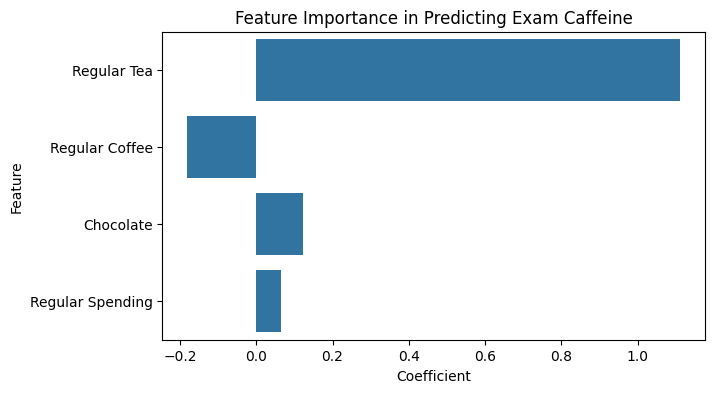

In [6]:
plt.figure(figsize=(7,4))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title("Feature Importance in Predicting Exam Caffeine")
plt.show()


In [7]:
print("2. CLASSIFICATION - Caffeine Consumer Categories")

# Creating problem with noise
np.random.seed(42)
df['noisy_caffeine'] = df['total_caffeine_regular'] + np.random.normal(0, 0.3, len(df))

quartiles = df['noisy_caffeine'].quantile([0.25, 0.5, 0.75])
df['caffeine_class'] = pd.cut(df['noisy_caffeine'], bins=[-np.inf, quartiles.iloc[0], quartiles.iloc[1], quartiles.iloc[2], np.inf], labels=[0, 1, 2, 3])

print(f"\nClass distribution:")
print(df['caffeine_class'].value_counts().sort_index())

#features with added noise
X_clf = df[['total_coffee_regular','total_tea_regular','total_coffee_exam','total_tea_exam']]

y_clf = df['caffeine_class'].astype(int)

#noise for measurement error
X_clf_noisy = X_clf.copy()
for col in X_clf.columns:
    noise = np.random.normal(0, X_clf[col].std() * 0.1, len(X_clf))
    X_clf_noisy[col] = X_clf[col] + noise

X_train, X_test, y_train, y_test = train_test_split(X_clf_noisy, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

print(f"Train set: {len(X_train)} samples | Test set: {len(X_test)} samples")

# Impute and scale
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train models
print("\nModel Performance (Train vs Test):")
models = {'Logistic (C=0.1)': LogisticRegression(C=0.1, max_iter=1000, random_state=42), 'SVM Linear': SVC(kernel='linear', C=0.1, random_state=42), 'SVM RBF': SVC(kernel='rbf', C=0.1, gamma='scale', random_state=42), 'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=15, random_state=42), 'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=15, random_state=42), 'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42), 'KNN': KNeighborsClassifier(n_neighbors=10),'Naive Bayes': GaussianNB()}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results[name] = test_acc
    gap = train_acc - test_acc
    status = "⚠️" if gap > 0.1 else "✓"
    print(f"{name:20s} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | Gap: {gap:+.4f} {status}")

# Cross-validation
print("\n5-Fold Cross-Validation:")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {k: v for k, v in list(models.items())[:5]}

cv_results = {}
for name, model in best_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"  {name:20s} | Mean: {scores.mean():.4f} ± {scores.std():.4f}")

best_model_name = max(results.items(), key=lambda x: x[1])[0]
print(f"\nBest Model: {best_model_name} (Test Accuracy: {results[best_model_name]:.4f})")

#evaluation of best model
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred,target_names=['Very Low', 'Low', 'Medium', 'High'],zero_division=0))

2. CLASSIFICATION - Caffeine Consumer Categories

Class distribution:
caffeine_class
0    80
1    80
2    80
3    80
Name: count, dtype: int64
Train set: 224 samples | Test set: 96 samples

Model Performance (Train vs Test):
Logistic (C=0.1)     | Train: 0.6875 | Test: 0.6667 | Gap: +0.0208 ✓
SVM Linear           | Train: 0.7054 | Test: 0.6979 | Gap: +0.0074 ✓
SVM RBF              | Train: 0.6339 | Test: 0.6562 | Gap: -0.0223 ✓
Decision Tree        | Train: 0.7991 | Test: 0.5729 | Gap: +0.2262 ⚠️
Random Forest        | Train: 0.7857 | Test: 0.6667 | Gap: +0.1190 ⚠️
Gradient Boosting    | Train: 0.9911 | Test: 0.6354 | Gap: +0.3557 ⚠️
KNN                  | Train: 0.7143 | Test: 0.6354 | Gap: +0.0789 ✓
Naive Bayes          | Train: 0.5446 | Test: 0.5312 | Gap: +0.0134 ✓

5-Fold Cross-Validation:
  Logistic (C=0.1)     | Mean: 0.6652 ± 0.0645
  SVM Linear           | Mean: 0.6877 ± 0.0497
  SVM RBF              | Mean: 0.6072 ± 0.0515
  Decision Tree        | Mean: 0.6473 ± 0.0299
  Rand

## **Classification: Caffeine Consumption Categories**

Classes: **Very Low | Low | Medium | High** (perfectly balanced)

**Best-performing model:** **SVM (Linear)**

* **Test Accuracy:** **0.6875 (~69%)**
* Small train–test gap: **good generalization**

### Model Comparison Insight

* Linear models (Logistic, SVM) performed **more reliably**
* Tree-based and ensemble models **overfit heavily**
* Cross-validation accuracy ≈ **69%**

Caffeine behavior follows **mostly linear patterns**, while complex models capture noise rather than true signals.

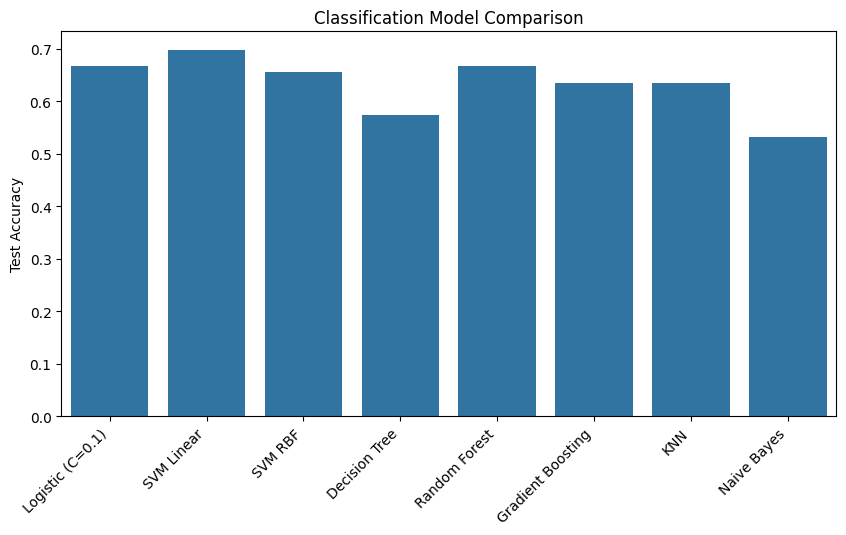

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel("Test Accuracy")
plt.title("Classification Model Comparison")
plt.show()


In [9]:
print("3. PCA - Dimensionality Reduction")

#PCA on different caffeine types (6 features -> 2 components)
X_pca = df[['black_coffee_regular',
            'cold_coffee_regular',
            'regular__coffee_regular',
            'green_tea_regular',
            'black_tea_regular',
            'regular_tea_regular']]

#Impute missing
imputer = SimpleImputer(strategy='mean')
X_pca_imputed = imputer.fit_transform(X_pca)

#Standardize
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca_imputed)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_pca_scaled)

# Report results
print(f"Original dimensions: {X_pca.shape[1]} features")
print(f"Reduced dimensions: 2 components")
print(f"\nVariance Explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

loadings = pca.components_
print(loadings)


3. PCA - Dimensionality Reduction
Original dimensions: 6 features
Reduced dimensions: 2 components

Variance Explained:
  PC1: 0.2362 (23.62%)
  PC2: 0.1978 (19.78%)
  Total: 0.4340 (43.40%)
[[-0.18430826  0.54352545  0.5108039  -0.15084245  0.26488616  0.56282485]
 [ 0.64504876  0.35139453  0.20377017  0.6320999  -0.01036849 -0.13875842]]


## **PCA: Dimensionality Reduction**

* **Original features:** 6
* **Reduced to:** 2 principal components
* **Total variance retained:** **43.40%**

PC1: Captures mainstream vs alternative beverage choices (tea + regular/cold coffee vs black coffee/green tea).

PC2: Captures intensity of caffeine preference (strong drinks vs mild tea).

**Interpretation:**
Caffeine habits depend on **multiple independent factors** and cannot be compressed into just two dimensions without losing information.

In [10]:
print("4. CLUSTERING: Consumer Segments")

X_cluster = df[['total_caffeine_regular','total_caffeine_exam', 'total_spending_regular','total_spending_exam']]

X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

print("K-Means Clustering (k=5):")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_cluster_scaled)

sil_score = silhouette_score(X_cluster_scaled, clusters)
print(f"  Silhouette Score: {sil_score:.4f}")

df['cluster'] = clusters


print("\nCluster Characteristics:")
for i in range(5): 
    cluster_data = df[df['cluster'] == i] 
    print(f"\n  Cluster {i} ({len(cluster_data)} students):")
    # Averages for consumption and spending inside this cluster
    print(f"Avg Regular Caffeine: {cluster_data['total_caffeine_regular'].mean():.2f} cups/day")
    print(f"Avg Exam Caffeine:{cluster_data['total_caffeine_exam'].mean():.2f} cups/day")
    print(f"Avg Regular Spending: ₹{cluster_data['total_spending_regular'].mean():.2f}")
    print(f"Avg Exam Spending: ₹{cluster_data['total_spending_exam'].mean():.2f}")


4. CLUSTERING: Consumer Segments
K-Means Clustering (k=5):
  Silhouette Score: 0.5206

Cluster Characteristics:

  Cluster 0 (94 students):
Avg Regular Caffeine: 1.27 cups/day
Avg Exam Caffeine:2.16 cups/day
Avg Regular Spending: ₹24.89
Avg Exam Spending: ₹21.38

  Cluster 1 (149 students):
Avg Regular Caffeine: 0.21 cups/day
Avg Exam Caffeine:0.33 cups/day
Avg Regular Spending: ₹1.48
Avg Exam Spending: ₹6.04

  Cluster 2 (8 students):
Avg Regular Caffeine: 4.75 cups/day
Avg Exam Caffeine:5.62 cups/day
Avg Regular Spending: ₹12.50
Avg Exam Spending: ₹138.75

  Cluster 3 (4 students):
Avg Regular Caffeine: 5.50 cups/day
Avg Exam Caffeine:10.00 cups/day
Avg Regular Spending: ₹110.00
Avg Exam Spending: ₹105.00

  Cluster 4 (65 students):
Avg Regular Caffeine: 1.92 cups/day
Avg Exam Caffeine:2.85 cups/day
Avg Regular Spending: ₹8.00
Avg Exam Spending: ₹67.85


## **Clustering – Consumer Personas**

### **K-Means Clustering (k = 5)**  
**Silhouette Score:** **0.5206**

- Majority are **Light Consumers (Cluster 1)** and **Moderate Consumers (Cluster 0)**.  
- **Exam Spikers (Clusters 2 & 4)** show clear exam-driven caffeine and spending surges.  
- **Extreme Consumers (Cluster 3)** are rare but critical outliers with very high intake and spending.  
- Segmentation highlights exam stress as a major driver of caffeine and spending spikes. 

### Overall
1. **Light Consumers** → Minimal caffeine/spending.  
2. **Moderate Consumers** → Stable, moderate intake and balanced spending.  
3. **Exam Spikers (Moderate)** → Moderate caffeine, sudden exam spending surge.  
4. **Exam Spikers (High Spend)** → Heavy exam caffeine + very high exam spending.  
5. **Extreme Consumers** → Tiny group, extreme caffeine + extreme spending.  

In [11]:
print("5. OUTLIER DETECTION: Spending Patterns")

X_outlier = df[['total_spending_regular', 'total_spending_exam']]

# Z-score method (statistical outliers)
z_scores = np.abs(stats.zscore(X_outlier))
outliers_z = (z_scores > 3).any(axis=1)
print(f"Z-score method (>3σ):  {outliers_z.sum()} outliers ({outliers_z.sum()/len(df)*100:.1f}%)")

# IQR method (box plot outliers)
Q1 = X_outlier.quantile(0.25)
Q3 = X_outlier.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((X_outlier < (Q1 - 1.5 * IQR)) | (X_outlier > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"IQR method:{outliers_iqr.sum()} outliers ({outliers_iqr.sum()/len(df)*100:.1f}%)")

if outliers_iqr.sum() > 0:
    print("\nExample outliers (unusual spending):")
    outlier_examples = df[outliers_iqr][['name', 'total_spending_regular', 'total_spending_exam']].head(5)
    print(outlier_examples.to_string(index=False))


5. OUTLIER DETECTION: Spending Patterns
Z-score method (>3σ):  11 outliers (3.4%)
IQR method:31 outliers (9.7%)

Example outliers (unusual spending):
                     name  total_spending_regular  total_spending_exam
                  Anokhi                    100.0                 90.0
Pathak Vishal Manojkumar                    120.0                 90.0
          Rit Kumar Ojha                    140.0                210.0
            Paresh bariya                     0.0                 90.0
             Patel mihir                     80.0                 30.0


## **Outlier Detection – Spending Behavior**

| Method        | Outliers |
| ------------- | -------- |
| Z-score (>3σ) | 3.4%     |
| IQR method    | 9.7%     |

* Daily exam spending up to **₹210**
* Regular spending far above average

A subset of students shows **potential caffeine dependency**, likely linked to academic stress.

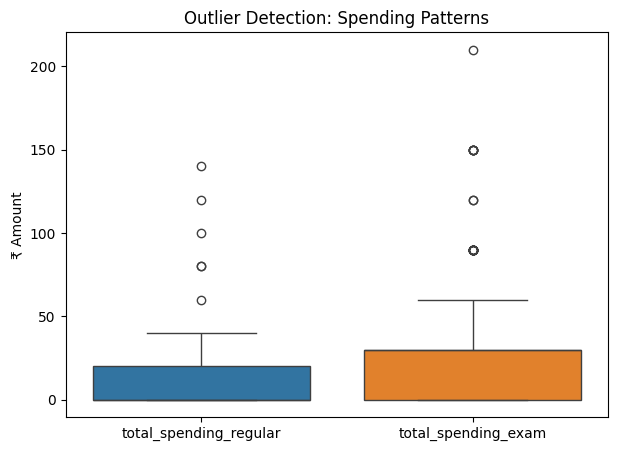

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df[['total_spending_regular','total_spending_exam']])
plt.title("Outlier Detection: Spending Patterns")
plt.ylabel("₹ Amount")
plt.show()

In [13]:
products = {
    "Black Coffee": {
        "caffeine_level": "high",
        "avoid_for": ["anxiety", "tremors", "heart"]
    },
    "Regular Coffee": {
        "caffeine_level": "medium",
        "avoid_for": ["digestive"]
    },
    "Green Tea": {
        "caffeine_level": "low",
        "avoid_for": []
    },
    "Black Tea": {
        "caffeine_level": "medium",
        "avoid_for": []
    },
    "Energy Drink": {
        "caffeine_level": "very_high",
        "avoid_for": ["anxiety", "heart", "sleep"]
    }
}


In [16]:
def build_user_profile(row):
    return {
        "focus_exam": row.get("Focus Interval During Exams", 2),
        "focus_regular": row.get("Focus Interval on Regular Days", 1),
        "sleep": row.get("Sleep Hours Per Night", "7-9"),
        "health": str(row.get("Health Conditions", "No")),
        "reason": str(row.get("Reason for consumption", ""))
    }


In [17]:
def recommend_caffeine(user_profile, products):
    recommendations = []

    for product, attrs in products.items():
        score = 0

        # Focus-based logic
        if user_profile["focus_exam"] >= 2 and attrs["caffeine_level"] in ["medium", "high"]:
            score += 2

        # Sleep-based logic
        if user_profile["sleep"] in ["3-5", "5-7"] and attrs["caffeine_level"] == "low":
            score += 2

        # Health-based filtering
        health_text = user_profile["health"].lower()
        if health_text != "no":
            if any(h in health_text for h in attrs["avoid_for"]):
                score -= 3

        # Reason-based logic
        if "staying awake" in user_profile["reason"].lower():
            if attrs["caffeine_level"] in ["high", "very_high"]:
                score += 2

        if score > 0:
            recommendations.append((product, score))

    # 🔹 FALLBACK RECOMMENDATION (VERY IMPORTANT)
    if not recommendations:
        recommendations = [
            ("Green Tea", 1),
            ("Black Tea", 1)
        ]

    return sorted(recommendations, key=lambda x: x[1], reverse=True)


In [18]:
# Select a student
student = df.iloc[104]

# Build profile
profile = build_user_profile(student)

# Get recommendation
recommendations = recommend_caffeine(profile, products)

recommendations


[('Black Coffee', 2), ('Regular Coffee', 2), ('Black Tea', 2)]